In [9]:
import pickle
from pathlib import Path
import numpy as np 

MODEL_PATH = Path("../models/som_model_4_features.pkl")  

with open(MODEL_PATH, "rb") as f:
    som_model = pickle.load(f)

print("Modell laddad")
#print(som_model.get_summary())

Modell laddad


In [10]:
import pandas as pd

df_test = pd.read_csv("../data/processed/eda_ppg_features_for_test/features_all_test.csv")

print("Rows:", len(df_test))
df_test.head()

Rows: 1510


,HR,HRV_RMSSD,RR_diff_std,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_quality,RR_valid,participant,time_sec,SC_PH,SC_RR,EDA_slope
0,81.206099,50.139805,50.075765,46.650290,738.860759,46.354095,555.0,835.0,79,0.961538,1,Part49,0,48.333613,0.116667,-0.000259
1,80.204637,42.250029,42.225870,46.827929,748.086420,46.537970,555.0,820.0,81,0.962500,1,Part49,15,52.456976,0.100000,-0.000249
2,79.892129,44.425968,44.419915,48.194184,751.012658,47.888186,555.0,820.0,79,0.961538,1,Part49,30,46.684711,0.100000,-0.000240
3,78.781247,35.611541,35.603014,30.605296,761.602564,30.408475,660.0,820.0,78,1.000000,1,Part49,45,25.272809,0.100000,-0.000218
4,79.404467,38.368632,38.363411,39.373053,755.625000,39.126198,625.0,820.0,80,1.000000,1,Part49,60,13.614164,0.100000,-0.000195


In [11]:
df_test["SC_PH"] = np.log1p(df_test["SC_PH"])
low, high = df_test["SC_PH"].quantile([0.01, 0.99])
df_test["SC_PH"] = df_test["SC_PH"].clip(low, high)

# --- SLOPE ---
low, high = df_test["EDA_slope"].quantile([0.01, 0.99])
df_test["EDA_slope"] = df_test["EDA_slope"].clip(low, high)

df = df_test[df_test["RR_quality"] > 0.7]

df_test.describe()

,HR,HRV_RMSSD,RR_diff_std,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_quality,RR_valid,time_sec,SC_PH,SC_RR,EDA_slope
count,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.000000,1510.0,1510.000000,1510.000000,1510.000000,1510.000000
mean,81.858844,47.269315,47.129126,57.217256,745.986818,56.854750,601.533113,903.615894,81.738411,0.959794,1.0,1125.000000,1.736934,0.073124,0.000052
std,11.206951,15.338508,15.219114,19.620101,96.505659,19.478995,93.606327,121.624625,11.086493,0.061747,0.0,654.051451,1.296738,0.042893,0.000213
min,59.770878,11.777810,11.771076,13.357261,487.605042,13.299562,405.000000,560.000000,60.000000,0.591549,1.0,0.000000,0.000564,0.000000,-0.000281
25%,73.156987,35.120797,35.092292,42.697108,678.252841,42.431060,535.000000,820.000000,73.000000,0.951951,1.0,555.000000,0.765075,0.050000,-0.000171
50%,80.895513,47.389605,47.258323,54.483334,741.697531,54.168646,610.000000,885.000000,81.000000,0.985507,1.0,1125.000000,1.474035,0.066667,0.000102
75%,88.462589,60.078704,59.870228,69.259644,820.154110,68.825410,670.000000,985.000000,88.000000,1.000000,1.0,1695.000000,2.482035,0.100000,0.000270
max,123.050409,85.409553,84.427196,119.787056,1003.833333,118.952293,855.000000,1195.000000,119.000000,1.000000,1.0,2250.000000,5.975952,0.366667,0.000288


In [12]:
features = [
    "HR",
    "HRV_RMSSD",
    "SC_PH",
    "SC_RR"
   
]

# Kontroll att features finns
missing = [f for f in features if f not in df_test.columns]
assert len(missing) == 0, f"Saknade features: {missing}"

df_test[features].describe()

,HR,HRV_RMSSD,SC_PH,SC_RR
count,1510.000000,1510.000000,1510.000000,1510.000000
mean,81.858844,47.269315,1.736934,0.073124
std,11.206951,15.338508,1.296738,0.042893
min,59.770878,11.777810,0.000564,0.000000
25%,73.156987,35.120797,0.765075,0.050000
50%,80.895513,47.389605,1.474035,0.066667
75%,88.462589,60.078704,2.482035,0.100000
max,123.050409,85.409553,5.975952,0.366667


In [13]:
df_test_clean = df_test.dropna(subset=features).copy()

print("Före:", len(df_test))
print("Efter:", len(df_test_clean))

Före: 1510
Efter: 1510


In [14]:
print(df_test_clean[features].describe())

                HR    HRV_RMSSD        SC_PH        SC_RR
count  1510.000000  1510.000000  1510.000000  1510.000000
mean     81.858844    47.269315     1.736934     0.073124
std      11.206951    15.338508     1.296738     0.042893
min      59.770878    11.777810     0.000564     0.000000
25%      73.156987    35.120797     0.765075     0.050000
50%      80.895513    47.389605     1.474035     0.066667
75%      88.462589    60.078704     2.482035     0.100000
max     123.050409    85.409553     5.975952     0.366667


In [15]:
import numpy as np

X_test = df_test_clean[features]

print("Har NaN:\n", X_test.isna().sum())

# Feature consistency
assert list(X_test.columns) == list(som_model.scaler.feature_names_in_)

Har NaN:
 HR           0
HRV_RMSSD    0
SC_PH        0
SC_RR        0
dtype: int64


AttributeError: 'dict' object has no attribute 'scaler'

In [16]:
X_test_scaled = pd.DataFrame(
    som_model.scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

print("Shape:", X_test_scaled.shape)

AttributeError: 'dict' object has no attribute 'scaler'

In [30]:
print(X_test_scaled.describe())
print("\nVariance:\n", X_test_scaled.var())

               HR   HRV_RMSSD
count  778.000000  778.000000
mean     0.356440    0.485422
std      0.135306    0.179431
min      0.131788    0.047843
25%      0.261422    0.342294
50%      0.330305    0.514119
75%      0.432951    0.629344
max      0.800848    0.857741

Variance:
 HR           0.018308
HRV_RMSSD    0.032195
dtype: float64


In function predict_cluster send df **WITHOUT** scaling

In [31]:
pred_clusters = som_model.predict_cluster(X_test)

# Säkerhet
assert len(pred_clusters) == len(df_test_clean)

df_test_clean["cluster"] = pred_clusters

print("Clusters tilldelade ✅")

🔍 INPUT (first 5 rows):
          HR  HRV_RMSSD
0  80.958913  46.875722
1  79.809691  47.851082
2  79.749864  52.143254
3  79.595306  65.115282
4  80.144513  70.288640
🔍 INPUT range:
min: HR           65.720822
HRV_RMSSD    12.878207
dtype: float64
max: HR           124.458572
HRV_RMSSD     82.465206
dtype: float64

🔍 AFTER scaling (first 5 rows):
[[0.30535956 0.44352784]
 [0.2922692  0.4548797 ]
 [0.29158773 0.50483475]
 [0.28982721 0.65581153]
 [0.29608303 0.71602239]]
🔍 AFTER scaling range:
min: 0.04784297349794729
max: 0.857741059572906

🔍 Unique BMUs: 266
🔍 Unique clusters: {np.int32(0), np.int32(1), np.int32(2)}
Clusters tilldelade ✅


In [32]:
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]

print("Unika BMUs:", len(set(bmus)))

Unika BMUs: 266


=== Cluster Distribution ===
cluster
1    0.415167
0    0.341902
2    0.242931
Name: proportion, dtype: float64

=== Per Participant ===
participant  cluster
49           1          0.646154
             2          0.292308
             0          0.061538
50           1          0.646154
             0          0.246154
             2          0.107692
51           2          0.861538
             1          0.138462
52           2          1.000000
53           0          0.692308
             1          0.307692
54           0          1.000000
55           0          0.603175
             1          0.396825
56           2          0.615385
             1          0.384615
57           1          0.861538
             0          0.107692
             2          0.030769
58           0          0.784615
             1          0.215385
59           1          0.861538
             0          0.138462
60           1          0.523077
             0          0.476923
Name: proportion,

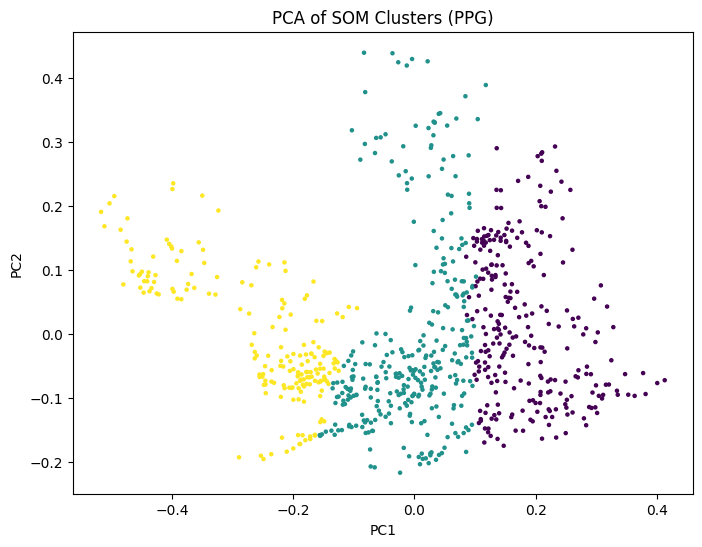


=== Cluster Interpretation ===

Cluster 0
HR           81.767333
HRV_RMSSD    65.951226
Name: 0, dtype: float64

Cluster 1
HR           84.942579
HRV_RMSSD    50.009292
Name: 1, dtype: float64

Cluster 2
HR           91.472928
HRV_RMSSD    29.490656
Name: 2, dtype: float64

Silhouette (neurons): 0.35118076486377847


In [35]:


import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. Klusterfördelning
print("=== Cluster Distribution ===")
print(df_test_clean["cluster"].value_counts(normalize=True))

# 2. Per participant
print("\n=== Per Participant ===")
print(df_test_clean.groupby("participant")["cluster"].value_counts(normalize=True))

# 3. Kluster means
print("\n=== Cluster Means ===")
cluster_means = df_test_clean.groupby("cluster")[features].mean()
print(cluster_means)

# 4. Kluster std
print("\n=== Cluster STD ===")
print(df_test_clean.groupby("cluster")[features].std())

# 5. Label mapping
cluster_labels = {
    0: "Rest",
    1: "Neutral/active",
    2: "Stress"
}

df_test_clean["cluster_label"] = df_test_clean["cluster"].map(cluster_labels)

print("\n=== Cluster Labels Distribution ===")
print(df_test_clean["cluster_label"].value_counts(normalize=True))

# 6. PCA visualisering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_test_clean["cluster"],
    s=5
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of SOM Clusters (PPG)")
plt.show()

# 7. Fysiologisk tolkning
print("\n=== Cluster Interpretation ===")
for c in sorted(df_test_clean["cluster"].unique()):
    print(f"\nCluster {c}")
    print(cluster_means.loc[c])

# 8. Silhouette (på neuroner - snabbt)
try:
    weights = som_model.som.get_weights().reshape(-1, len(features))
    labels = som_model.kmeans.labels_
    score = silhouette_score(weights, labels)
    print("\nSilhouette (neurons):", score)
except:
    print("\nSilhouette kunde inte beräknas (saknar kmeans i modellen)")

In [36]:
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]

cluster_labels = []

for bmu in bmus:
    idx = bmu[0] * som_model.som._weights.shape[1] + bmu[1]
    cluster_labels.append(som_model.kmeans.labels_[idx])

print(set(cluster_labels))

{np.int32(0), np.int32(1), np.int32(2)}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# k-means labels över SOM grid
labels_map = som_model.kmeans.labels_.reshape(30, 30)

plt.figure(figsize=(6,6))
plt.imshow(labels_map, cmap='tab10')
plt.title("SOM cluster regions")
plt.colorbar()

# overlay dina BMUs
bmus = [som_model.som.winner(x) for x in X_test_scaled.values]
xs = [b[0] for b in bmus]
ys = [b[1] for b in bmus]

plt.scatter(ys, xs, s=1, c='white')  # overlay
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    X_test_scaled["HR"],
    X_test_scaled["HRV_RMSSD"],
    s=2
)
plt.title("Test data in feature space")
plt.show()

In [34]:
# ===== SHOW ALL WINDOWS WITH FEATURES + CLUSTER =====



# 1. Reset index och skapa window_id
df_test_clean = df_test_clean.reset_index(drop=True)
df_test_clean["window_id"] = df_test_clean.index

# 2. Cluster labels
cluster_labels = {
    0: "Neutral/Base",
    1: "Rest/Recovery",
    2: "Stress"
}

df_test_clean["cluster_label"] = df_test_clean["cluster"].map(cluster_labels)

# 3. Välj kolumner
df_windows = df_test_clean[[
    "window_id",
    "HR",
    "HRV_RMSSD",
    "cluster",
    "cluster_label"
]]

# 4. Visa ALLA rader (63 st)
pd.set_option("display.max_rows", None)

print("\n=== ALL WINDOWS (HR + RMSSD + CLASS) ===\n")
print(df_windows)

# 5. (Valfritt) Snygg utskrift rad för rad
print("\n=== READABLE FORMAT ===\n")
for _, row in df_windows.iterrows():
    print(f"Window {int(row['window_id']):02d} | "
          f"HR: {row['HR']:.1f} | "
          f"RMSSD: {row['HRV_RMSSD']:.1f} | "
          f"{row['cluster_label']}")

# 6. (Valfritt) Spara till fil
# df_windows.to_csv("window_classification.csv", index=False)


=== ALL WINDOWS (HR + RMSSD + CLASS) ===

     window_id          HR  HRV_RMSSD  cluster  cluster_label
0            0   80.958913  46.875722        1  Rest/Recovery
1            1   79.809691  47.851082        1  Rest/Recovery
2            2   79.749864  52.143254        1  Rest/Recovery
3            3   79.595306  65.115282        0   Neutral/Base
4            4   80.144513  70.288640        0   Neutral/Base
5            5   81.886532  72.061817        0   Neutral/Base
6            6   80.699415  63.623240        0   Neutral/Base
7            7   78.746196  44.811919        1  Rest/Recovery
8            8   77.644152  42.453897        1  Rest/Recovery
9            9   76.236059  40.594540        1  Rest/Recovery
10          10   75.904844  41.699537        1  Rest/Recovery
11          11   76.142769  43.813178        1  Rest/Recovery
12          12   75.536928  39.669007        1  Rest/Recovery
13          13   74.564227  40.294294        1  Rest/Recovery
14          14   74.957740 